<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/2_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Pre-Processing for Neural Networks**

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [110]:
# Data manipulation
import pandas as pd
import numpy as np
import os
import pickle

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
# Provide path
data=pd.read_csv('/content/drive/MyDrive/Customer_Churn_Data.csv')

# Make a copy of the original dataset
data_copy = data.copy()
df_nn = data_copy

## Handle Incorrect Data Types

In [112]:
# Create a numeric column for TotalCharges and drop object column
df_nn['TotalCharges_numeric'] = pd.to_numeric(df_nn['TotalCharges'], errors='coerce')
df_nn = df_nn.drop('TotalCharges', axis=1)

# Check for missing values after conversion
missing_total_charges = df_nn['TotalCharges_numeric'].isnull().sum()
print(f"Missing values in TotalCharges_numeric: {missing_total_charges}")

Missing values in TotalCharges_numeric: 11


In [113]:
# Display rows with missing TotalCharges_numeric
missing_rows = df_nn[df_nn['TotalCharges_numeric'].isnull()]
missing_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges_numeric
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,No,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,No,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,No,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,No,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,No,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,No,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,No,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,No,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,No,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,No,NaN


Calculation for imputation

In [114]:
# Calculate the difference for non-missing rows
mask_non_missing = df_nn['TotalCharges_numeric'].notna()
df_nn['calc_total'] = df_nn['MonthlyCharges'] * df_nn['tenure']
df_nn['diff'] = df_nn['TotalCharges_numeric'] - df_nn['calc_total']

# Calculate mean difference
mean_diff = df_nn.loc[mask_non_missing, 'diff'].mean()
print(f"Mean difference to use for imputation: {mean_diff:.2f}")

# Impute missing TotalCharges_numeric
mask_missing = df_nn['TotalCharges_numeric'].isna()
df_nn.loc[mask_missing, 'TotalCharges_numeric'] = (
    df_nn.loc[mask_missing, 'MonthlyCharges'] * df_nn.loc[mask_missing, 'tenure'] + mean_diff
)

# Drop helper columns
df_nn.drop(columns=['calc_total', 'diff'], inplace=True)

# Verify no missing values remain
print(df_nn['TotalCharges_numeric'].isna().sum())

Mean difference to use for imputation: 0.15
0


## Removing Irrelevant Columns

In [115]:
# Drop customerID
df_nn = df_nn.drop('customerID', axis=1)

## Check for numeric columns and negative values (To use Chi - Square Test)

In [116]:
# Separate features and target
X = df_nn.drop('Churn', axis=1)
y = df_nn['Churn']

# Check numeric columns
numeric_cols = X.select_dtypes(include=np.number).columns

# Check for negative values
for col in numeric_cols:
    if (X[col] < 0).any():
        print(f"Column '{col}' has negative values")

# Check for NaNs or infinite values
print(X[numeric_cols].isnull().sum())
print(np.isinf(X[numeric_cols]).sum())

SeniorCitizen           0
tenure                  0
MonthlyCharges          0
TotalCharges_numeric    0
dtype: int64
SeniorCitizen           0
tenure                  0
MonthlyCharges          0
TotalCharges_numeric    0
dtype: int64


## Apply Chi-Square after temporary Label Encoding

Categorical columns (excluding 'Churn'): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Top 12 Features with Chi-Squared Scores:
TotalCharges_numeric    624292.336899
tenure                   16278.923685
MonthlyCharges            3680.787699
Contract                  1115.780167
OnlineSecurity             551.611529
TechSupport                523.303866
OnlineBackup               230.086520
DeviceProtection           191.303140
SeniorCitizen              134.351545
Dependents                 133.036443
PaperlessBilling           105.680863
Partner                     82.412083
dtype: float64


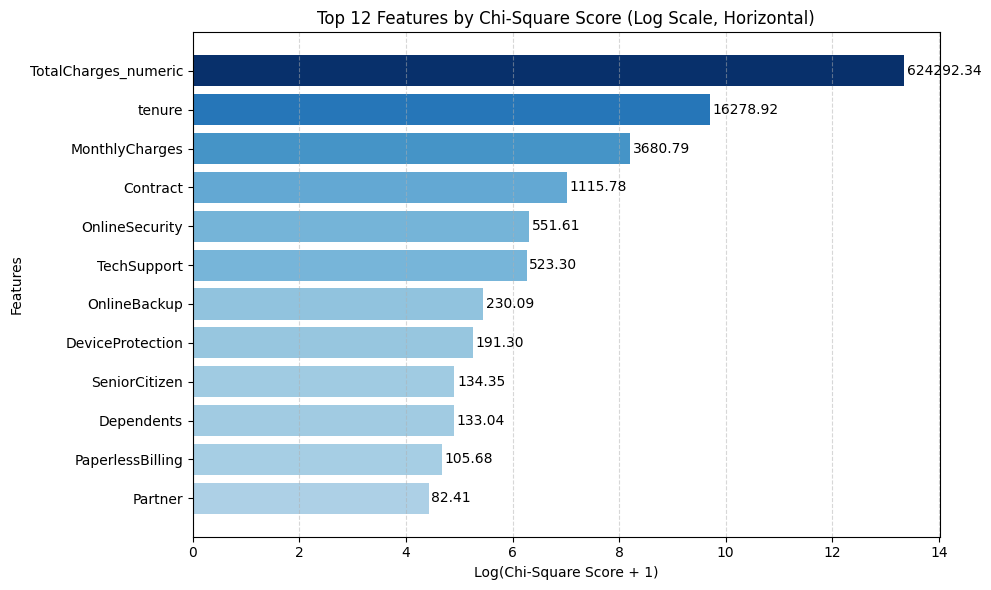

In [118]:
# Identify categorical columns (excluding target)
categorical_columns = df_nn.select_dtypes(include='object').columns.drop('Churn').tolist()
print("Categorical columns (excluding 'Churn'):", categorical_columns)

# Temporary Label Encoding for Chi-Square
df_label = df_nn.copy()
for col in categorical_columns:
    df_label[col] = LabelEncoder().fit_transform(df_label[col])

# Encode target for Chi-Square
y = df_label['Churn'].map({'No': 0, 'Yes': 1})
X = df_label.drop('Churn', axis=1)

# Apply Chi-Square to select top k features
k = 12
selector = SelectKBest(score_func=chi2, k=k)
selector.fit(X, y)

chi_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
top_features = chi_scores.head(k)
print("Top 12 Features with Chi-Squared Scores:")
print(top_features)

# Plot
# Log-transform the top 12 features
log_scores = np.log1p(top_features)
log_scores = log_scores.sort_values()

# Normalize
norm_scores = log_scores / log_scores.max()
colors = plt.cm.Blues(norm_scores.values)

# Plot horizontal bars
plt.figure(figsize=(10,6))
bars = plt.barh(log_scores.index, log_scores.values, color=colors)
plt.xlabel('Log(Chi-Square Score + 1)')
plt.ylabel('Features')
plt.title('Top 12 Features by Chi-Square Score (Log Scale, Horizontal)')

# Add grid
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value labels (original chi-square score)
for bar, raw_score in zip(bars, top_features.sort_values().values):
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, f'{raw_score:.2f}', va='center')

plt.tight_layout()
plt.show()

## One-Hot Encode on selected 12 features only

In [119]:
# Keep only top features in original df-nn
selected_features = top_features.index.tolist()
df_nn = df_nn[selected_features + ['Churn']]

# One-hot encoding only on selected categorical columns
selected_cat_cols = [col for col in categorical_columns if col in selected_features]
df_nn = pd.get_dummies(df_nn, columns=selected_cat_cols, drop_first=True)

# Convert boolean columns to int
bool_cols = df_nn.select_dtypes(include='bool').columns
df_nn[bool_cols] = df_nn[bool_cols].astype(int)

# Encode target variable Churn
df_nn['Churn'] = df_nn['Churn'].map({'No': 0, 'Yes': 1})

# Check final dataset
print("Shape after encoding:", df_nn.shape)
print("Columns after encoding:", df_nn.columns.tolist())

Shape after encoding: (7043, 18)
Columns after encoding: ['TotalCharges_numeric', 'tenure', 'MonthlyCharges', 'SeniorCitizen', 'Churn', 'Partner_Yes', 'Dependents_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes']


## Detect Outliers

In [120]:
# IQR method to detect outliers
num_features = ['TotalCharges_numeric', 'MonthlyCharges', 'tenure']

for col in num_features:
    Q1 = df_nn[col].quantile(0.25)
    Q3 = df_nn[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_nn[(df_nn[col] < lower_bound) | (df_nn[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

TotalCharges_numeric: 0 outliers
MonthlyCharges: 0 outliers
tenure: 0 outliers


## Check if Numerical Columns need Skew Handling

In [122]:
# Checking if skew handling should be done to the numerical columns
df_nn[['TotalCharges_numeric', 'MonthlyCharges', 'tenure']].skew()

,0
TotalCharges_numeric,0.963235
MonthlyCharges,-0.220524
tenure,0.239540


## Apply Log tranform for skewness

In [123]:
# Log transform (Skew handling)
df_nn['TotalCharges_numeric'] = np.log1p(df_nn['TotalCharges_numeric'])

## Scaling numerical features

In [124]:
# List of numerical features to scale
num_features = ['TotalCharges_numeric', 'MonthlyCharges', 'tenure']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the numerical features and transform
df_nn[num_features] = scaler.fit_transform(df_nn[num_features])

# Check the result
print(df_nn[num_features].describe())

       TotalCharges_numeric  MonthlyCharges       tenure
count           7043.000000     7043.000000  7043.000000
mean               0.760647        0.462803     0.449599
std                0.175693        0.299403     0.341104
min                0.000000        0.000000     0.000000
25%                0.655076        0.171642     0.125000
50%                0.795181        0.518408     0.402778
75%                0.907028        0.712438     0.763889
max                1.000000        1.000000     1.000000


## Choose X and Y and split the data

In [125]:
# Choose features (X) and target (y)
X = df_nn.drop(columns=['Churn'])
y = df_nn['Churn']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 17)
X_test shape: (1409, 17)
y_train shape: (5634,)
y_test shape: (1409,)


## Save the splitted data to drive

In [126]:
project_path = '/content/drive/MyDrive/NN_Model/Data_Splits/'

# Create the folder if it does not exist
os.makedirs(project_path, exist_ok=True)

# Save X_train
with open(os.path.join(project_path, 'X_train.pkl'), 'wb') as f:
    pickle.dump(X_train, f)

# Save X_test
with open(os.path.join(project_path, 'X_test.pkl'), 'wb') as f:
    pickle.dump(X_test, f)

# Save y_train
with open(os.path.join(project_path, 'y_train.pkl'), 'wb') as f:
    pickle.dump(y_train, f)

# Save y_test
with open(os.path.join(project_path, 'y_test.pkl'), 'wb') as f:
    pickle.dump(y_test, f)

## Save final preprocessed data to drive

In [127]:
df_nn.to_csv("/content/drive/MyDrive/NN_Model/processed_data_NN.csv", index=False)
print("Saved successfully!")

Saved successfully!
